In [1]:
# Importing Libraries
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 1

Text(0.5, 1.0, 'Distribution of Hourly Salaries for Data Scientist Jobs')

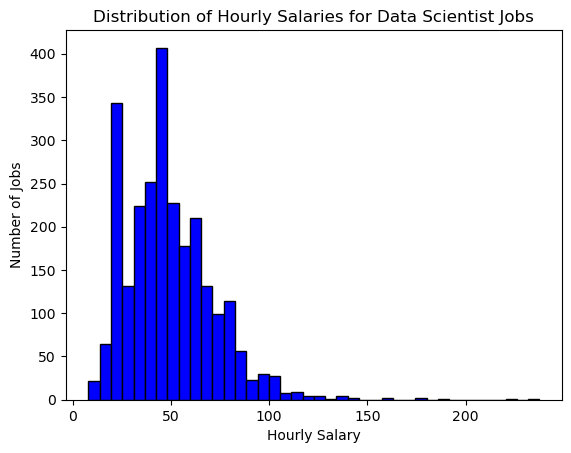

In [7]:
df_DS = df[df['job_title_short'] == 'Data Scientist'].copy()
df_DS = df_DS.dropna(subset=['salary_hour_avg'])
plot = df_DS['salary_hour_avg'].plot(kind='hist', bins=40, color='blue', edgecolor='black')
plot
plt.xlabel('Hourly Salary')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Hourly Salaries for Data Scientist Jobs')

## 2

Text(0, 0.5, 'Number of Job Postings')

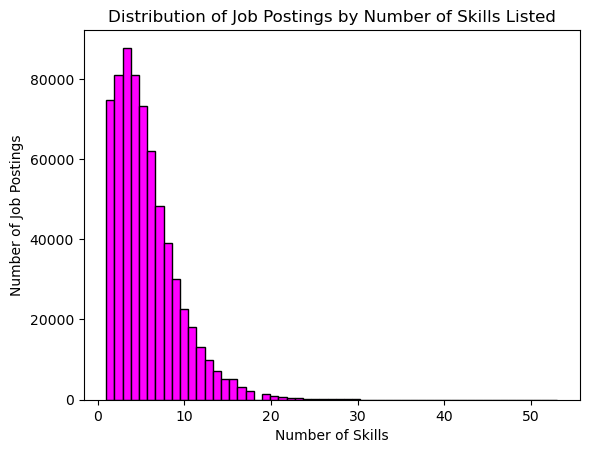

In [17]:
df_skills = df.dropna(subset=['job_skills']).copy()
df_skills['num_skills'] = df_skills['job_skills'].apply(len)
df_skills['num_skills'].plot(kind='hist', bins=55, color='magenta', edgecolor='black')
plt.title('Distribution of Job Postings by Number of Skills Listed')
plt.xlabel('Number of Skills')
plt.ylabel('Number of Job Postings')

## 3

Text(0, 0.5, 'Number of Jobs')

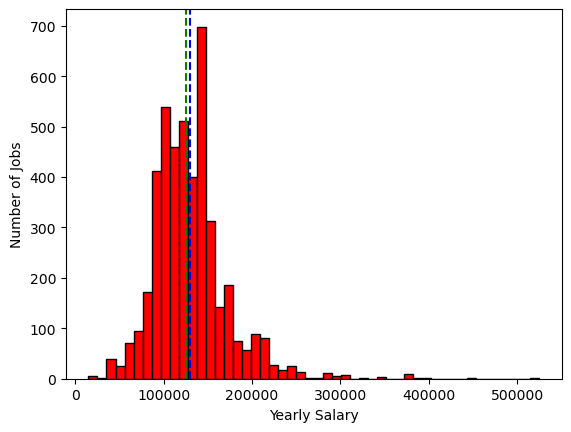

In [19]:
df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()
df_DE['salary_year_avg'].plot(kind='hist', bins=50, color='red', edgecolor='black')
mean_salary = df_DE['salary_year_avg'].mean()
median_salary = df_DE['salary_year_avg'].median()
plt.axvline(mean_salary, color='blue', linestyle='dashed', label=f'Mean: ${mean_salary:,.0f}')
plt.axvline(median_salary, color='green', linestyle='dashed', label=f'Median: ${median_salary:,.0f}')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')